# Analyze global fit results

In [1]:
import numpy as np
import sys
import os
import subprocess
import matplotlib as mpl
from matplotlib import pyplot as plt

mpl.rcParams["figure.dpi"] = 125
mpl.rcParams["savefig.dpi"] = 600


sys.path.append(os.path.abspath("/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/"))

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport fit_utils
%aimport fit_utils.utils
%aimport fit_utils.pullplots
%aimport fit_utils.parser
%aimport fit_utils.EFT_matching

import fit_utils.utils as utils
import fit_utils.pullplots as pullplots
import fit_utils.parser as parser
import fit_utils.EFT_matching as EFT_matching

In [9]:
model = "IDM"
working_dir = "."

all_scenarios = [
    # f"{model}_FCCee240"
    f"{model}_FCCee240_FCCee365"
    # f"{model}_FCCee240_FCCee365_HLLHClambda"
]

specs = [
    # "fits_long",
    # "fits_full",
    # # "fits_realistic_HL_LHC_pure_1L_BSM_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_small_priors_long",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_noLoopH3d6Quad_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_realistic_HL_LHC_long",
    # "fits_realistic_HL_LHC_all_EW_mods_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_sqrt_s_long",
    # "fits_realistic_HL_LHC_no_1L_BSM_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_sqrt_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_C_HG_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_no_cross_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_smeft_formula_external_leg_small_priors_long",
    # "fits_realistic_HL_LHC_small_priors_long",
    # "fits_realistic_HL_LHC_no_quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_long",
    # "fits_realistic_HL_LHC_noLoopH3d6Quad_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_no_quad_long",
    # "fits_realistic_HL_LHC_LoopHd6noWFR_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_WFR_kala2_input_all_all_EW_mods_no_HLLHC_Higgs_small_priors_long",
    "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.0115_theoerr365_0.0114_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long",
    "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.0115_theoerr365_0.0114_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_strict",
]

# specs = ["fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_noLoopH3d6Quad_small_priors_long"]

# spec_labels_dict = {
#     "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_long" : "Original",
#     "fits_realistic_HL_LHC_use_HEPfit_C1_values_WFR_kala2_input_all_all_EW_mods_small_priors_long" : "Using HEPfit C1 values",
#     "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long" : "Using HEPfit C1 values \n(including decay rates)",
#     "fits_realistic_HL_LHC_smeft_formula_all_small_priors_long" : "Using HEPfit formulas",
# }
spec_labels_dict = {
    # "fits_realistic_HL_LHC_WFR_kala2_input_all_all_EW_mods_small_priors_long" : "Original",
    # # "fits_realistic_HL_LHC_pure_1L_BSM_all_EW_mods_small_priors_long" : "Fit results",
    "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long" : "Original fits",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long" : r"With $\mathcal{O}(1/\Lambda^4)$",
    # "fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_noLoopH3d6Quad_small_priors_long" : r"No $\mathcal{O}(1/\Lambda^4)$"
    "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long" : r"Uncertainty estimates"+"\nw/o $\mathcal{O}(1/\Lambda^2)$ curve",
    # "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.0115_theoerr365_0.0114_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long" : "With new NPs",
    "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.0115_theoerr365_0.0114_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_strict" : r"Estimates with $\mathcal{O}(1/\Lambda^2)$ curve",
}
spec_labels = list(spec_labels_dict.values())

model_specs = {
    # f"{model}_FCCee240" : specs
    f"{model}_FCCee240_FCCee365" : specs,
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : specs,
}
scenario_titles_dict = {
    # f"{model}_FCCee240" : rf"FCC-ee$_{{240}}$",
    f"{model}_FCCee240_FCCee365" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$",
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : rf"FCC-ee$_{{240}}$ + FCC-ee$_{{365}}$ + $\kappa_{{\lambda}}$ at HL-LHC",
}
scenario_titles = list(scenario_titles_dict.values())

model_specs_labels = {
    # f"{model}_FCCee240" : specs
    f"{model}_FCCee240_FCCee365" : spec_labels,
    # f"{model}_FCCee240_FCCee365_HLLHClambda" : specs,
}


results_dirs = specs
# results_dirs = [ model_specs["IDM_FCCee240_FCCee365"] for spec in specs ]
# results_dir = "comparison_NPs_scaled"
# results_dir_compare = "comparison_original_HEPfitC1_C1decayrates_SMEFTformula"
# results_dir_compare = "comparison_original_with_NPs"
# results_dir_compare = "comparison_original_with_NPs_with_blue_curve"
# results_dir_compare = "comparison_with_without_order_1_Lambda4"
# results_dir_compare = "comparison_with_without_order_1_Lambda4_pure_1L_BSM"
results_dir_compare = specs[0]

# num_BPs = 8
# BPs = [f"BP_{i}" for i in range(num_BPs)]
BPs = []

# num_BPOs = 2
# BPOs = [f"BPO_{i}" for i in range(num_BPOs)]
BPOs = []

# num_BPBs = 17
# BPBs = [f"BPO_{i}" for i in range(num_BPBs)]
BPBs = ["BPB_2", "BPB_4", "BPB_6",]
# BPBs = []

# num_BPBnews = 14
# BPBnews = [f"BPBnew_{i}" for i in range(num_BPBnews)]
# BPBnews = ["BPBnew_0", "BPBnew_1", "BPBnew_2", "BPBnew_4", ]
BPBnews = ["BP_lambda1",]
# BPBnews = []

BPs = BPs + BPOs + BPBnews + BPBs

BP_names = [f"BP {i}" for i in range(len(BPs))]
# BP_names = ["BP 1", "BP 2", "BP 3"]

BP_lambdas = [
    1.1000242642433875, # BP_lambda1 
    2.3867362274064843, # BPB_2
    3.3446699219962595, # BPB_4
    4.332584967850238,  # BPB_6
]

plot_titles = { 
    scenario : { 
        # spec : f"{scenario_titles_dict[scenario]} scenario \n{spec_labels_dict[spec]}" 
        spec : f"{spec_labels_dict[spec]}" 
        for spec in model_specs[scenario] 
    } 
    for scenario in all_scenarios
}

<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
/jwd/tmp/ipykernel_6483/3107165767.py:71: SyntaxWarning: invalid escape sequence '\m'
  "fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long" : r"Uncertainty estimates"+"\nw/o $\mathcal{O}(1/\Lambda^2)$ curve",


## Copy kappa_lambda distributions to the `comparison_plots` directory

In [3]:
utils.group_plots(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
)

Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_pure_1L_BSM_all_EW_mods_small_priors_long/deltalHHH_HLLHC_mod_BP_lambda1_IDM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_pure_1L_BSM_all_EW_mods_small_priors_long/deltalHHH_HLLHC_mod_BPB_2_IDM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_pure_1L_BSM_all_EW_mods_small_priors_long/deltalHHH_HLLHC_mod_BPB_4_IDM_FCCee240_FCCee365.pdf
Succesfully copied plot to ./comparison_plots/results_fits_realistic_HL_LHC_pure_1L_BSM_all_EW_mods_small_priors_long/deltalHHH_HLLHC_mod_BPB_6_IDM_FCCee240_FCCee365.pdf


## Print $\kappa_\lambda$ results to a text file
For each model specification and collider scenario

In [5]:
utils.print_klam_results(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
)


Reading klam fit results
Reading file: ./BPB_2/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_4/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_4/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_6/IDM_FCCee240_FCCee365/results_fits_r

## Compare $\kappa_\lambda$ results between benchmark points
For each model specification and collider scenario


Reading klam fit results
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_4/IDM_FCCee240_FCCee365/resu

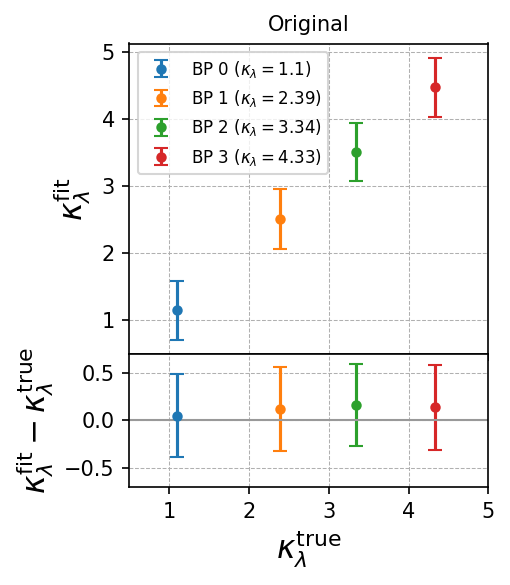

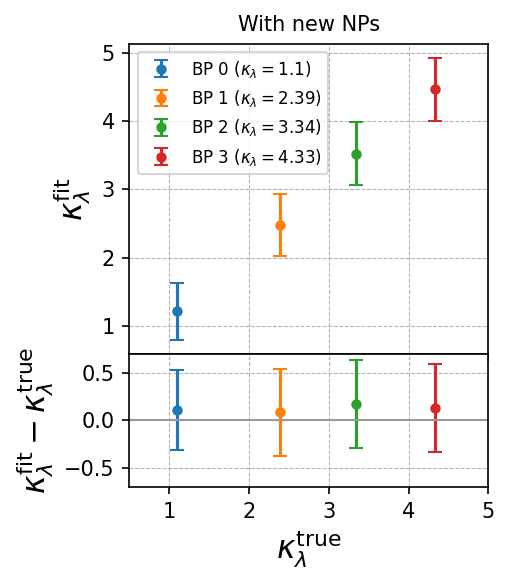

In [22]:
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",]
# colors = ["tab:blue", "tab:orange", "tab:green",]

utils.generate_klam_comparison_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dirs,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas,
    model=model,
    plot_labels=None,
    plot_titles=plot_titles,
    colors=colors,
    show_plots=True,
    x_lim = (0.5, 5.0),
    y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=8,
)


Reading klam fit results
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.0115_theoerr365_0.0114_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_strict/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365

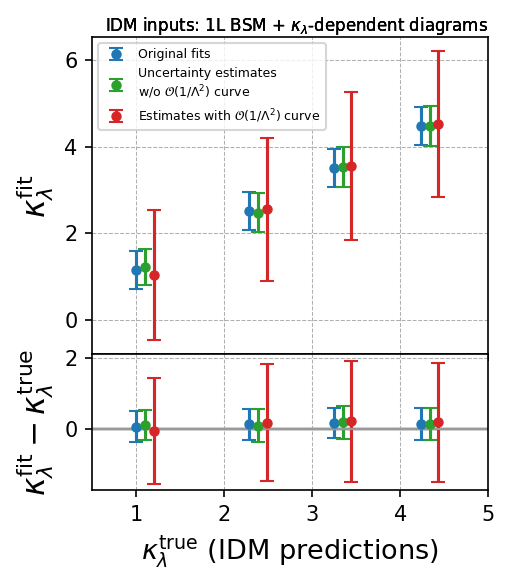


Reading klam fit results
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.0115_theoerr365_0.0114_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_strict/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365

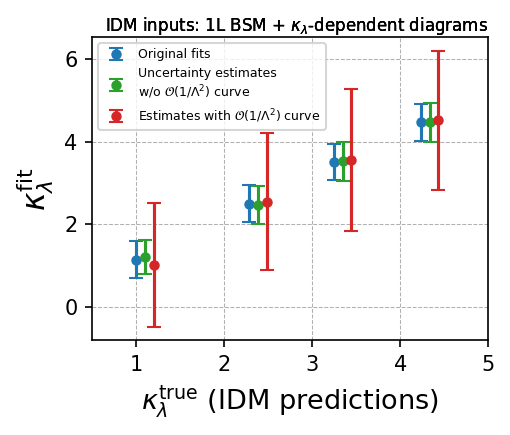

In [13]:
colors = ["tab:blue", "tab:green", "tab:red",]

utils.generate_klam_comparison_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    # # plot_true_klam={"color": "tab:red", "s": 50},
    plot_true_klam=None,
    show_plots=True,
    x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
)

utils.generate_klam_comparison_plot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dirs=results_dir_compare,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas,
    model=model,
    plot_labels=spec_labels,
    plot_titles=None,
    group_model_specs=True,
    colors=colors,
    # # plot_true_klam={"color": "tab:red", "s": 50},
    plot_true_klam=None,
    show_plots=True,
    x_lim = (0.5, 5.0),
    # y_lim_ax1=(0.2, 2.2),
    # y_lim_ax2=(-0.7, 0.7),
    leg_fontsize=6,
    spec_distance=0.2,
    # # upper_right_text=r"IDM inputs: strictly 1L BSM contributions",
    upper_right_text=r"IDM inputs: 1L BSM + $\kappa_\lambda$-dependent diagrams",
    no_bottom_axis=True,
    figsize=(3.5,3),
)

## Compare the posterior $\kappa_\lambda$ distribution between different model specifications

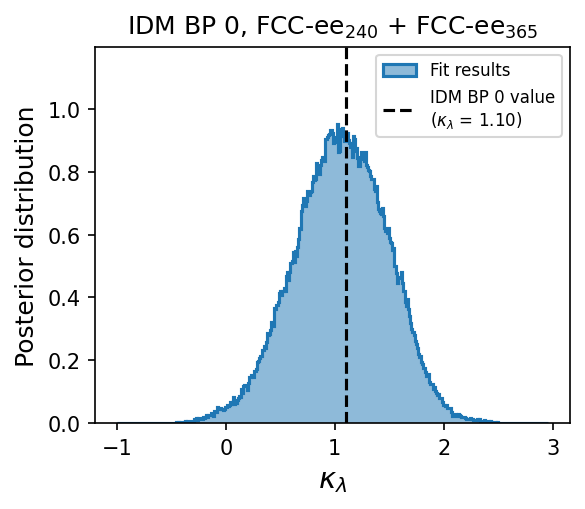

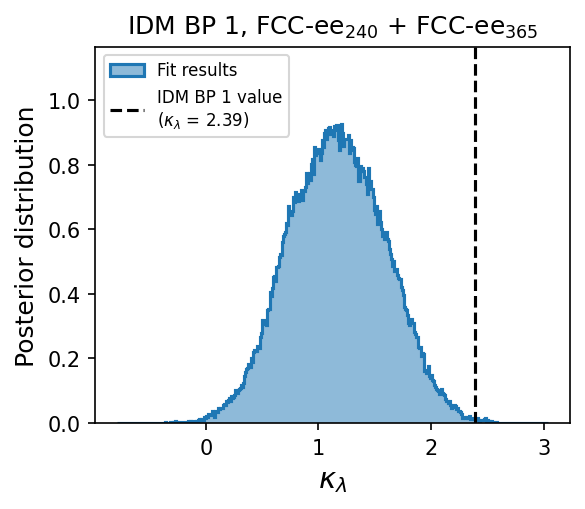

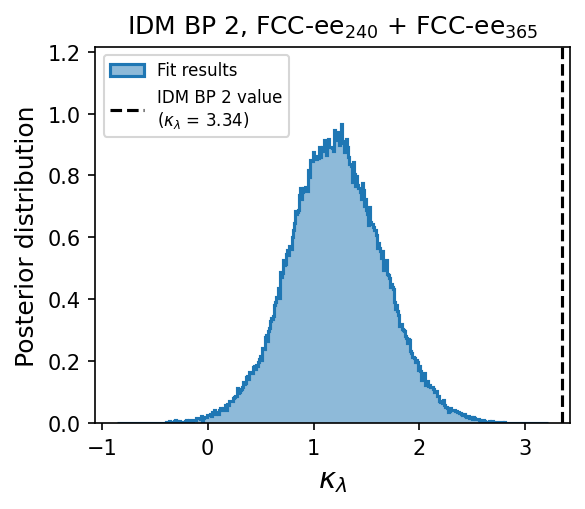

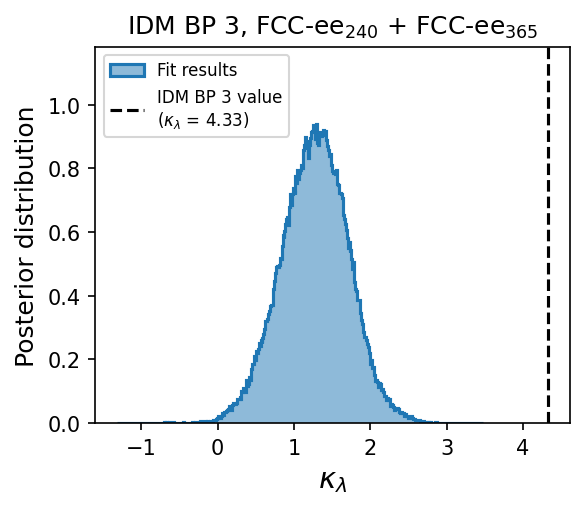

In [5]:
# colors = ["tab:blue", "tab:orange", "tab:green", "tab:red",]
colors = ["tab:blue", "tab:red",]

utils.compare_BP_results_uproot(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    spec_labels=spec_labels,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas,
    model=model,
    scenario_titles=None,
    plot_titles=None,
    colors=colors,
    show_plots=True,
    legend_fontsize=8.,
)

## Generate summary $\LaTeX$ table for $\kappa_\lambda$ results

In [26]:
utils.generate_klam_latex_table(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    spec_labels=spec_labels,
    BP_names=BP_names,
    BP_lambdas=BP_lambdas,
)


Reading klam fit results
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BP_lambda1/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_2/IDM_FCCee240_FCCee365/results_fits_realistic_HL_LHC_use_new_NPs_scale1.52_theoerr240_0.00107_theoerr365_0.00105_NPmismatch240_0_NPmismatch365_0_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long/Observables/Statistics.txt
Reading file: ./BPB_4/IDM_FCCee240_FCCee365/resu

## Generate pull plots for parameters


Finding configuration files for the observables

Setting configuration files for scenario: IDM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Setting configuration files for scenario: IDM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_noLoopH3d6Quad_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_noLoopH3d6Quad_small_priors_long
Files considered:
- Globalfits/AllOps/d6Ops_corr.conf

Reading configuration files for observables
Reading configuration file ./BP_lambda1/IDM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.conf
Found 29 observables



Reading configuration file ./BP_lambda1/IDM_FCCee240_FCCee365/Globalfits/AllOps/d6Ops_corr.c

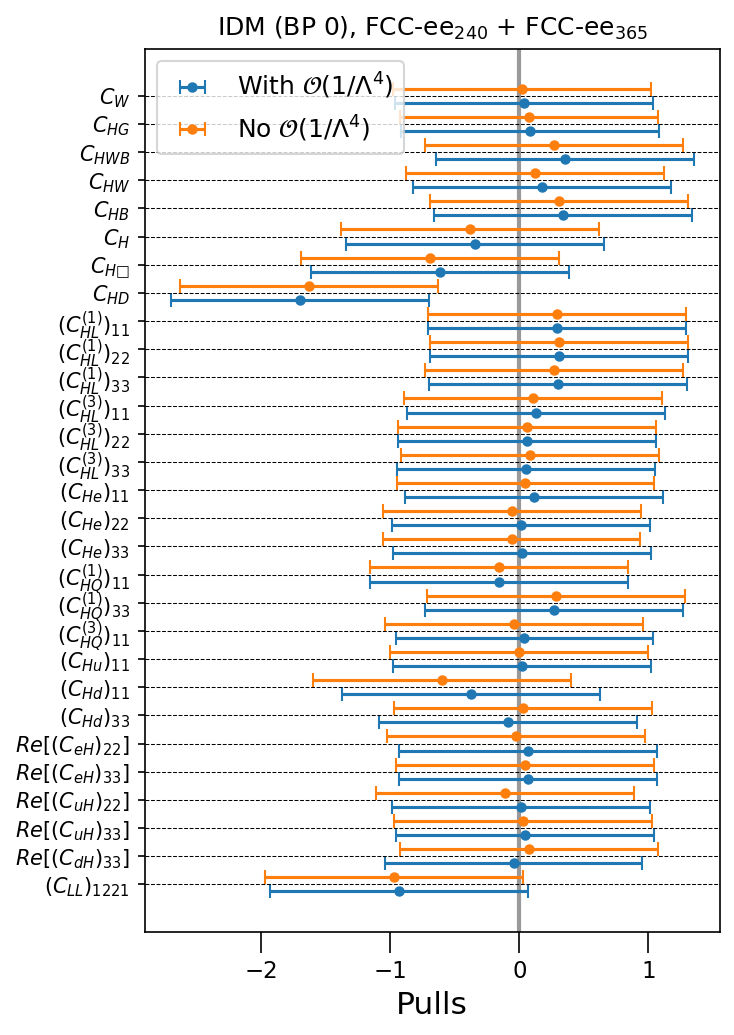

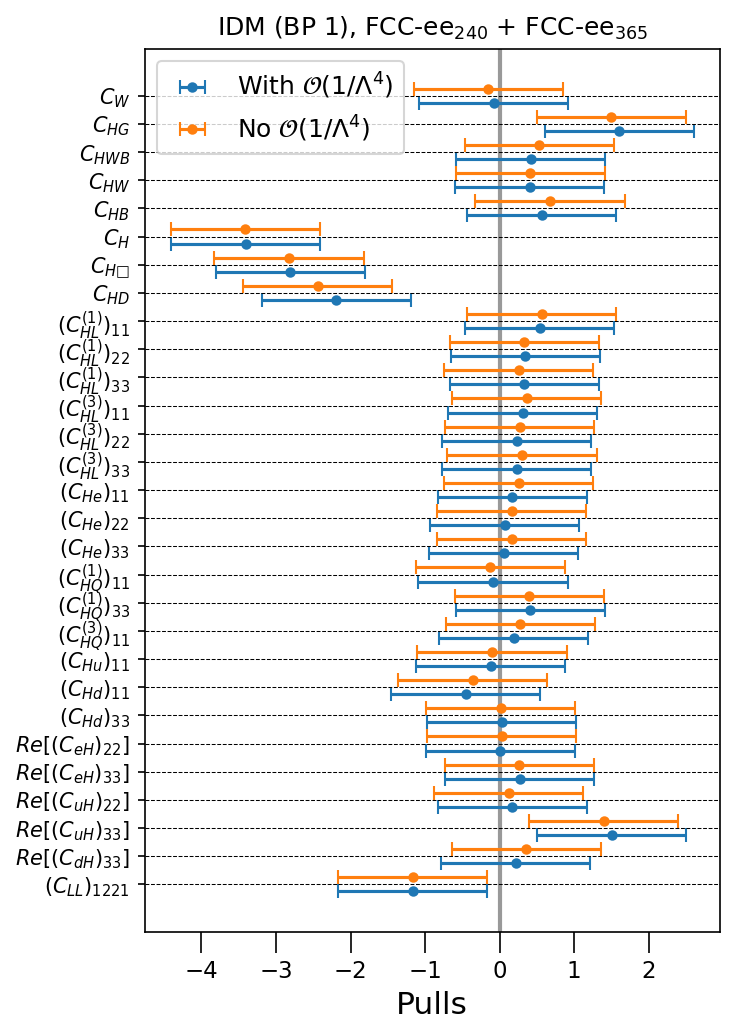

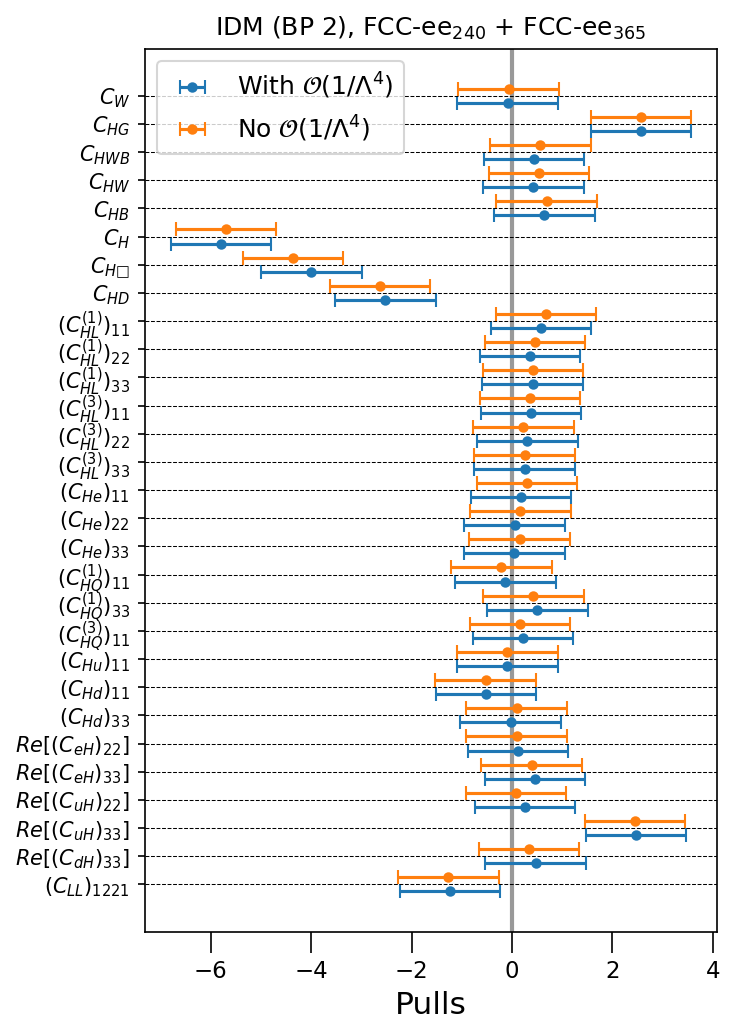

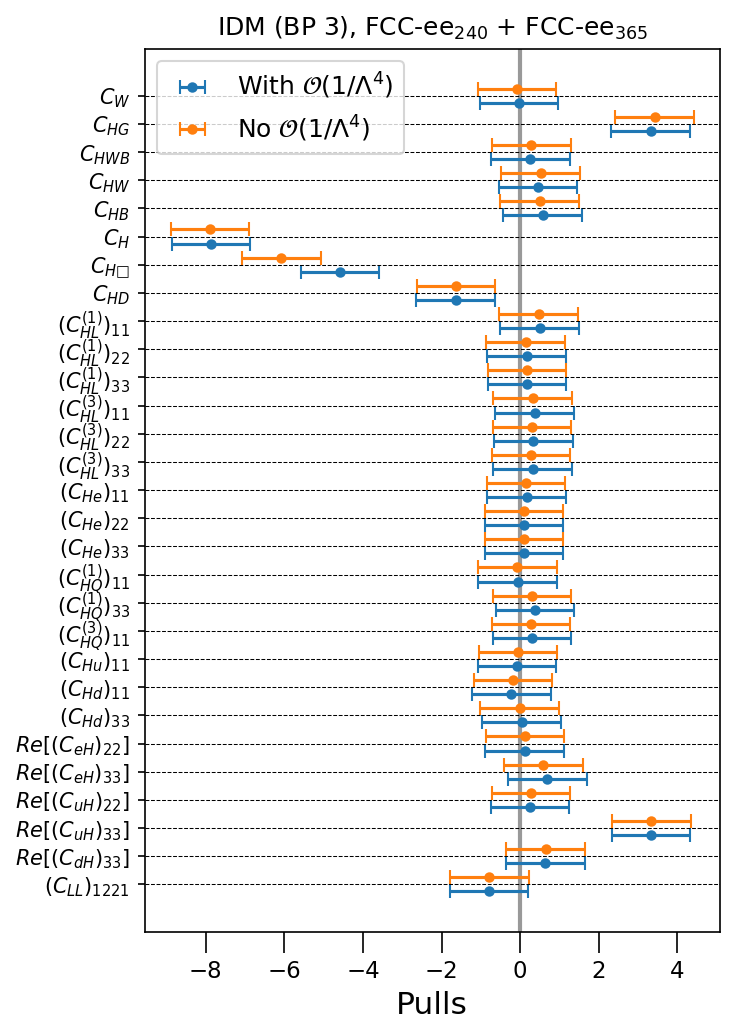

In [11]:
plot_titles = { 
    BP : {
        scenario : rf"{model} ({BP_name}), {scenario_title}"
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

pullplots.generate_pull_plots_pars(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 7),
)

## Generate pull plots for observables


Finding configuration files for the observables

Setting configuration files for scenario: IDM_FCCee240_FCCee365 model spec: fits_realistic_HL_LHC_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long
Full fit flag: use_HEPfit_C1_values_decayrates_WFR_kala2_input_all_all_EW_mods_small_priors_long
Files considered:
- ObservablesEW_all_mods.conf
- ObservablesEW_Current_SM_noLFU_kappa_scaled.conf
- ObservablesEW_FCCee_Zpole_SM_kappa_scaled.conf
- ObservablesEW_FCCee_WW_SM_kappa_scaled.conf
- ObservablesEW_HLLHC_kappa_scaled.conf
- ObservablesHiggs_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesHiggs_FCCee_240_SM_kappa_scaled_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesHiggs_HLLHC_SM_kappa_scaled_use_HEPfit_C1_values_decayrates_WFR_kala2_input_all.conf
- ObservablesVV.conf
- aTGC_observables_Current.conf
- aTGC_observables_HLLHC_Full.conf
- ObservablesVV_OO_FCCee_161.conf
- ObservablesVV_OO_FCCee_240.conf
- EffVH

/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][model_spec][:,1] / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][

135
[  0  50 100 135]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][model_spec][:,1] / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][

135
[  0  50 100 135]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][model_spec][:,1] / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][

135
[  0  50 100 135]


/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][model_spec][:,1] / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:331: RuntimeWarning: invalid value encountered in divide
  results_means  = np.copy((results[BP][scenario][model_spec][:,0] - central_values_obs[BP][scenario][model_spec]) / results[BP][scenario][model_spec][:,1] )
/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/fit_utils/pullplots.py:332: RuntimeWarning: invalid value encountered in divide
  results_errors = np.copy( results[BP][scenario][

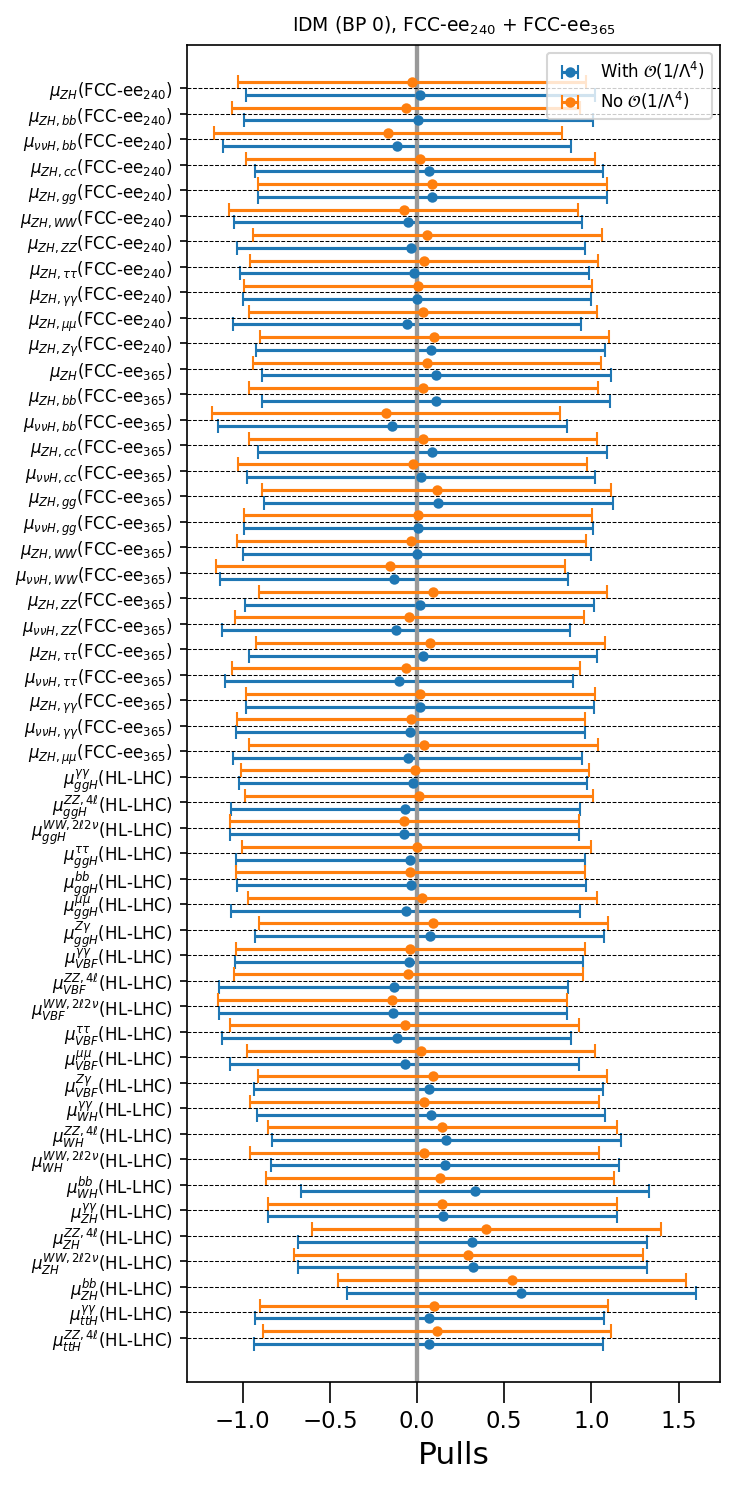

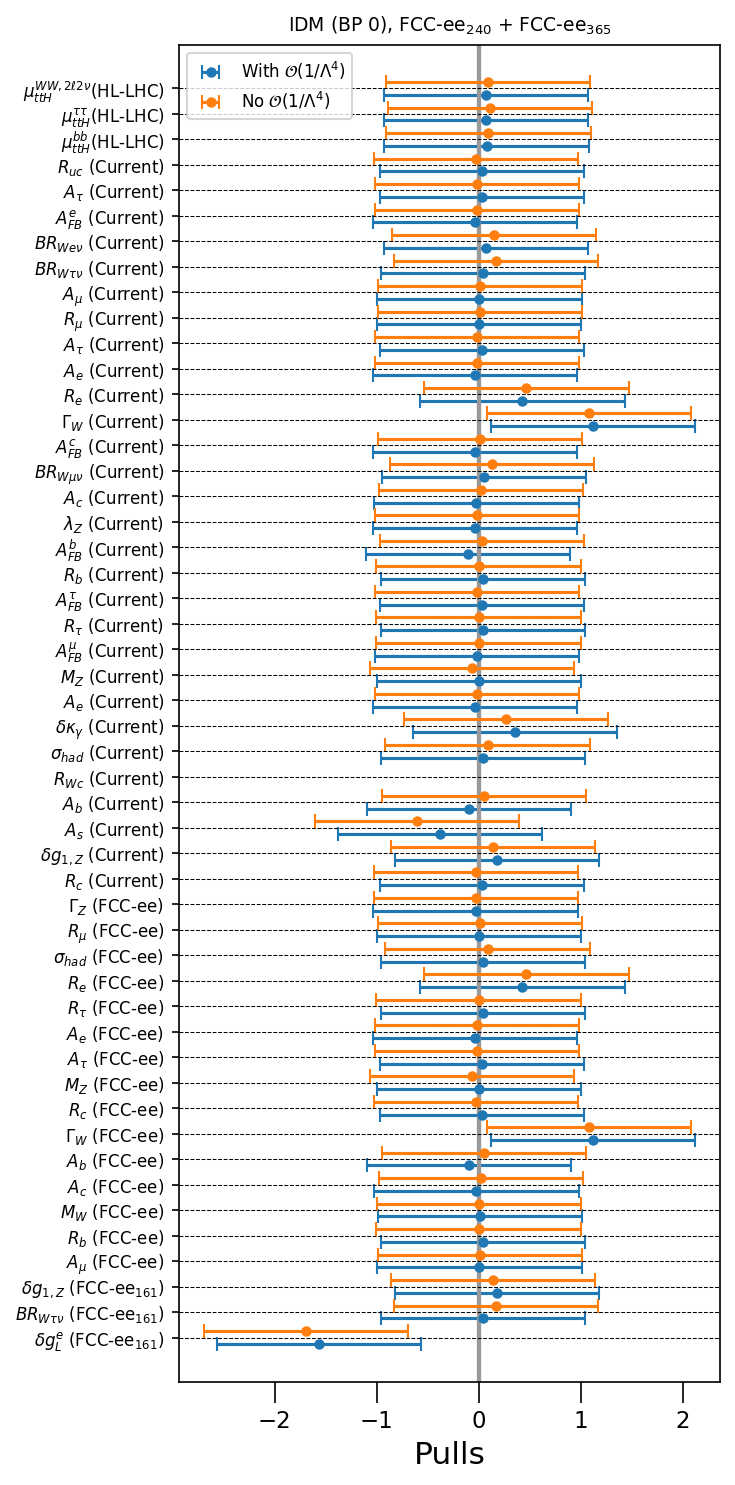

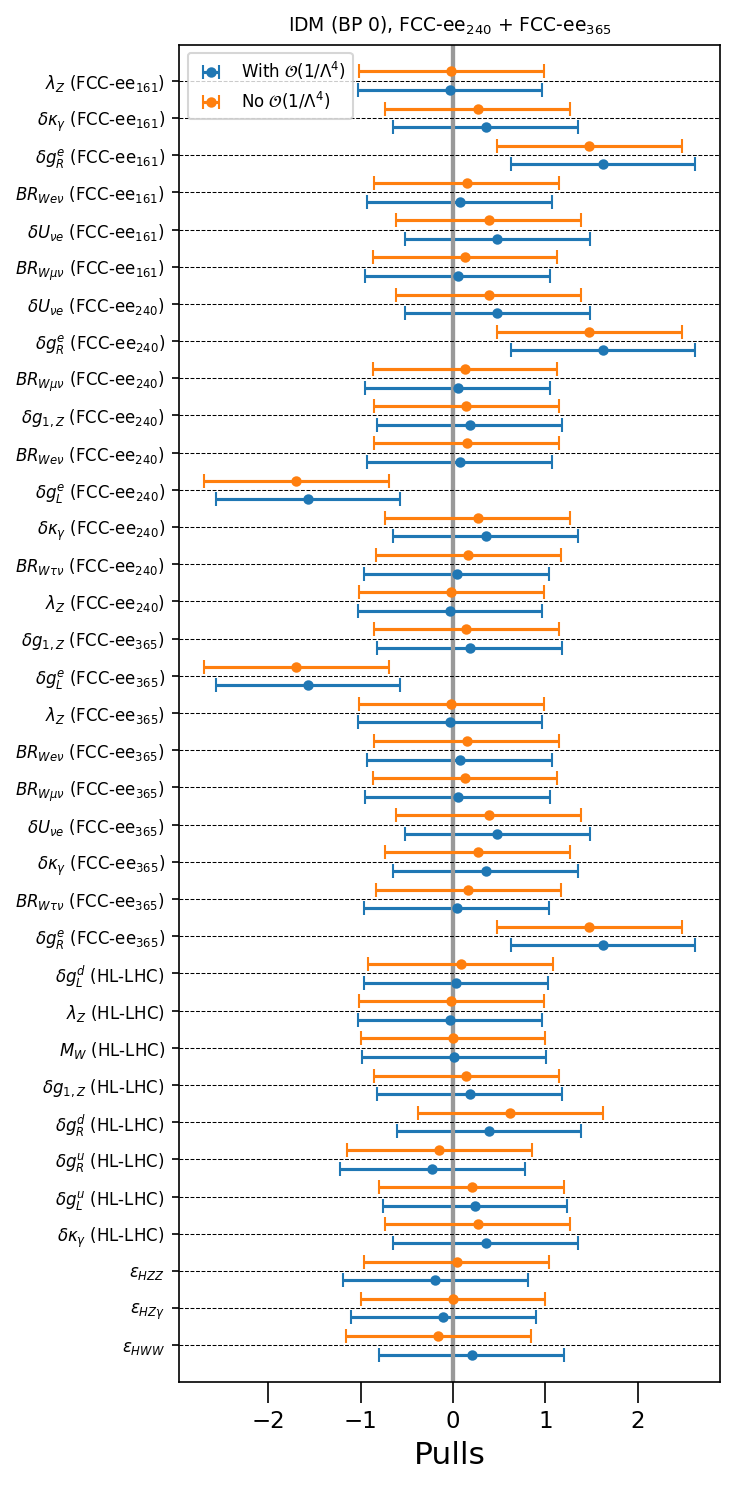

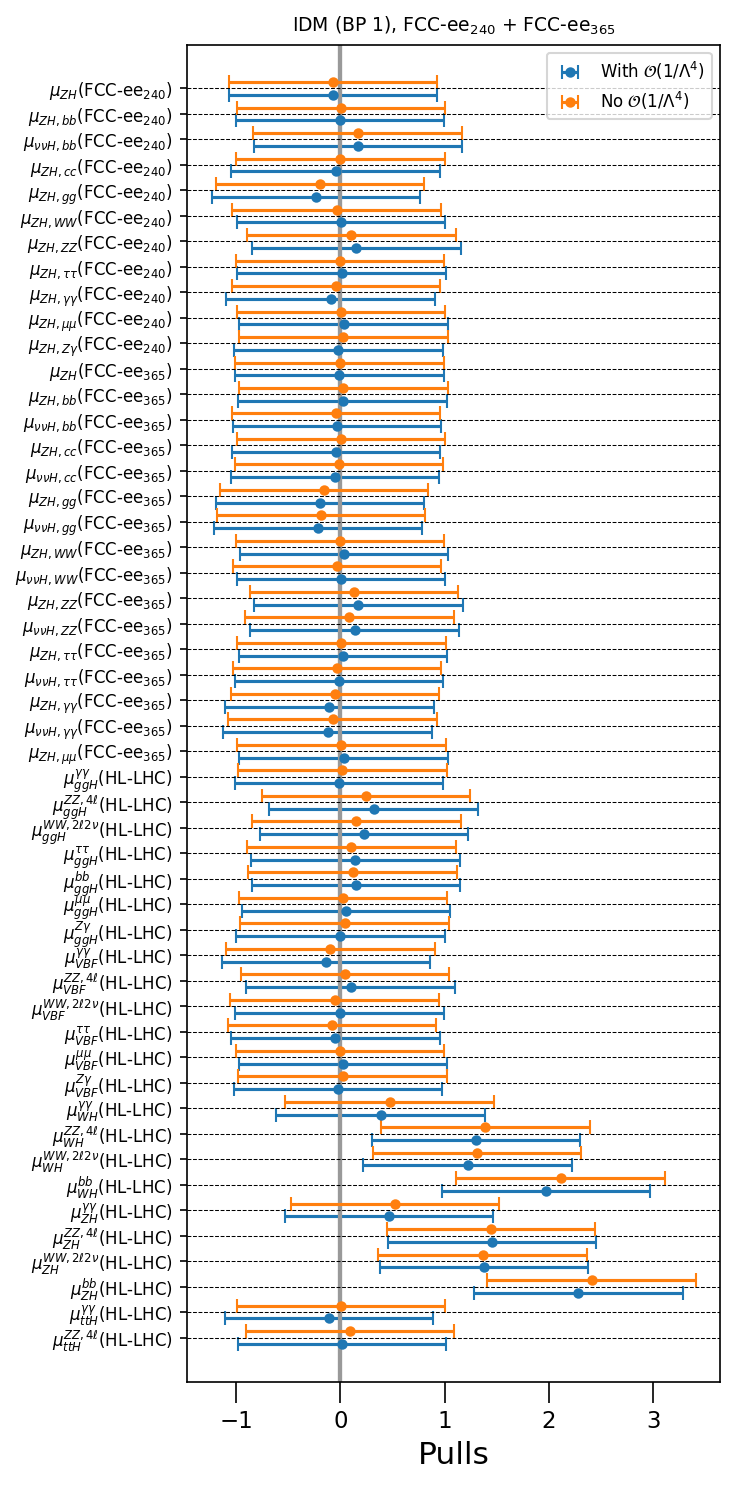

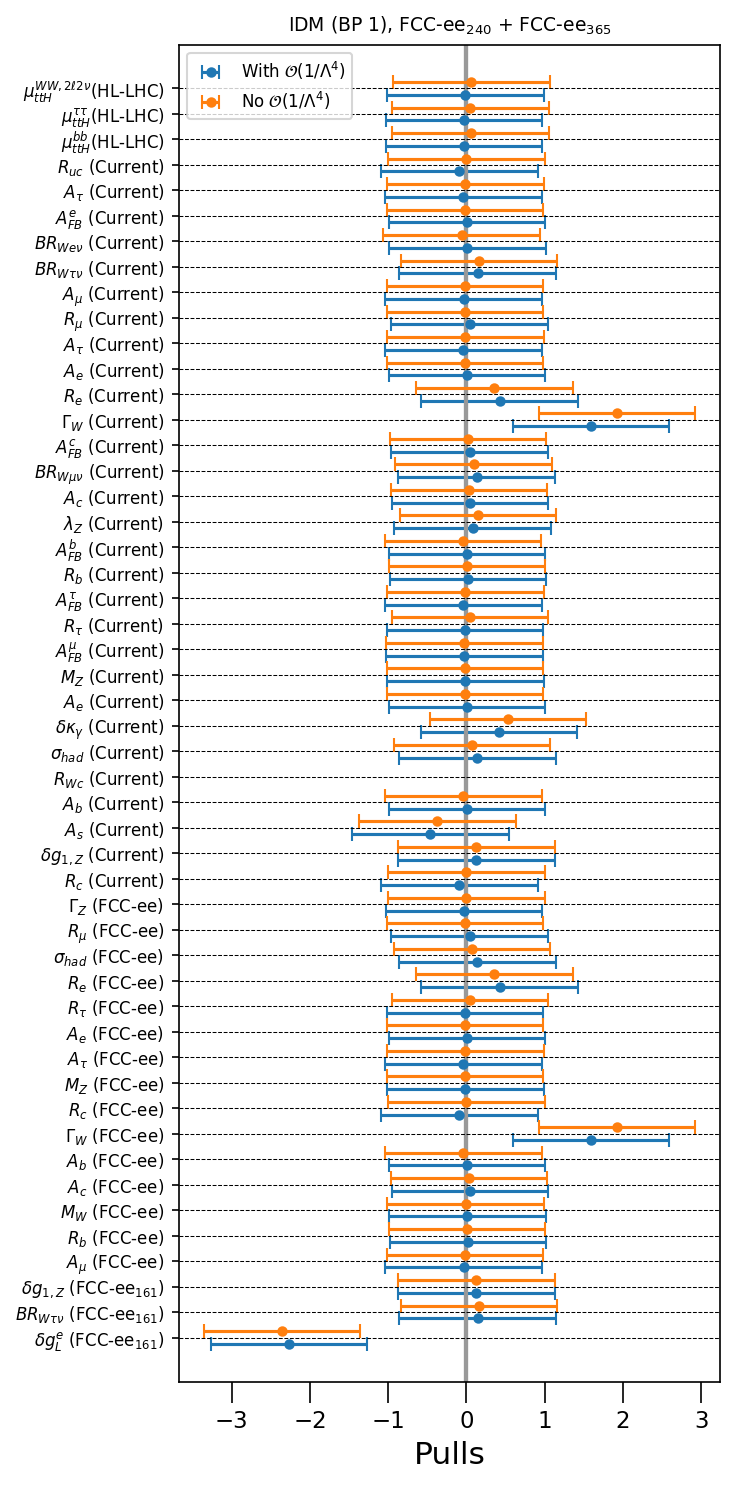

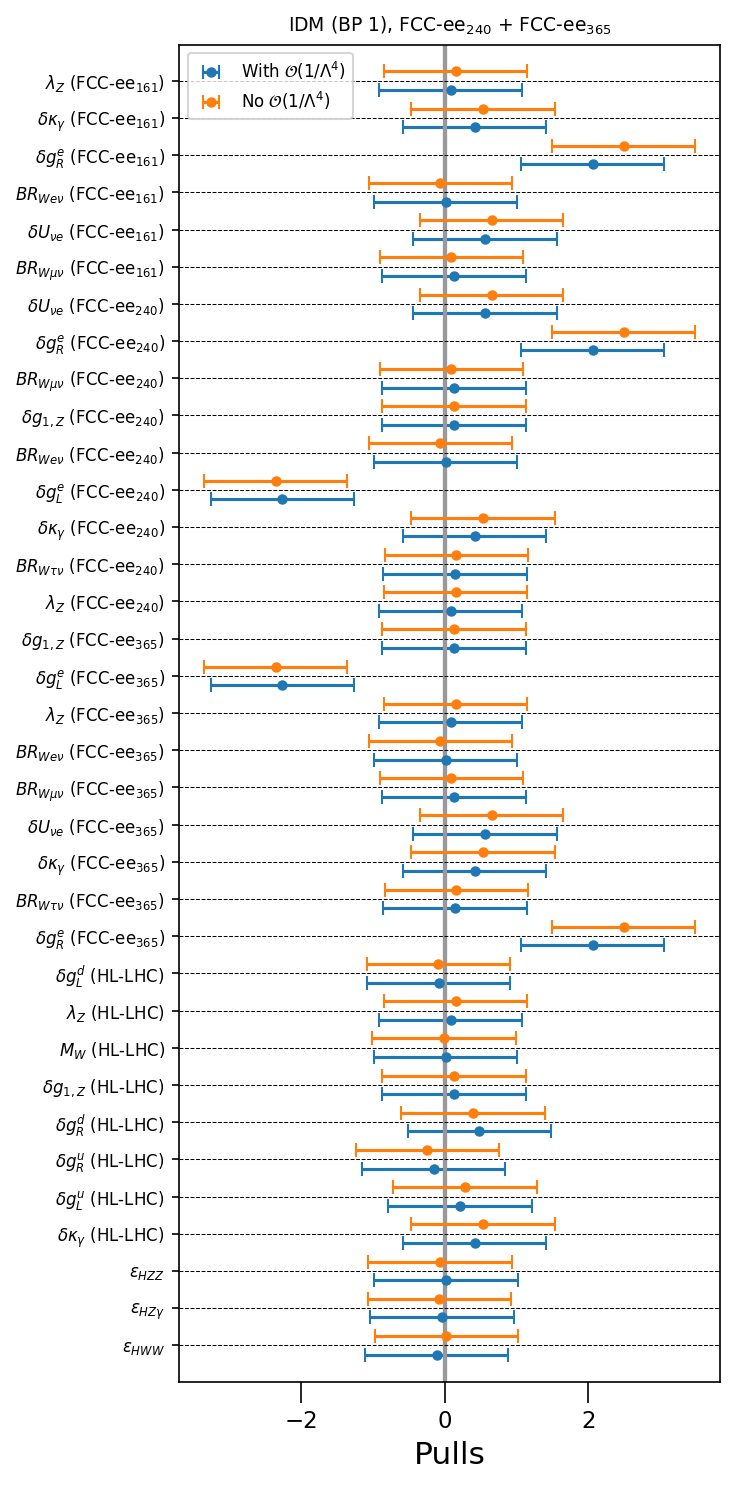

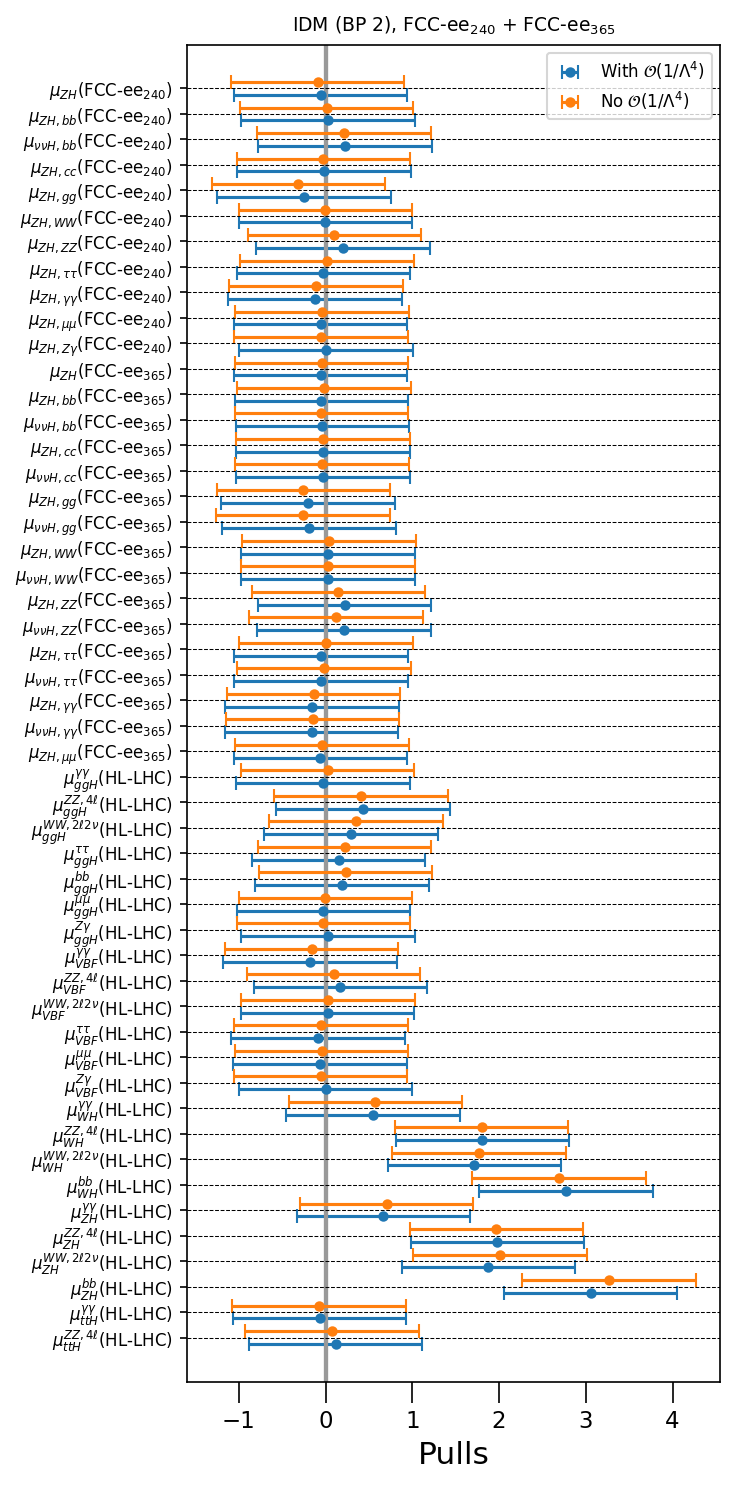

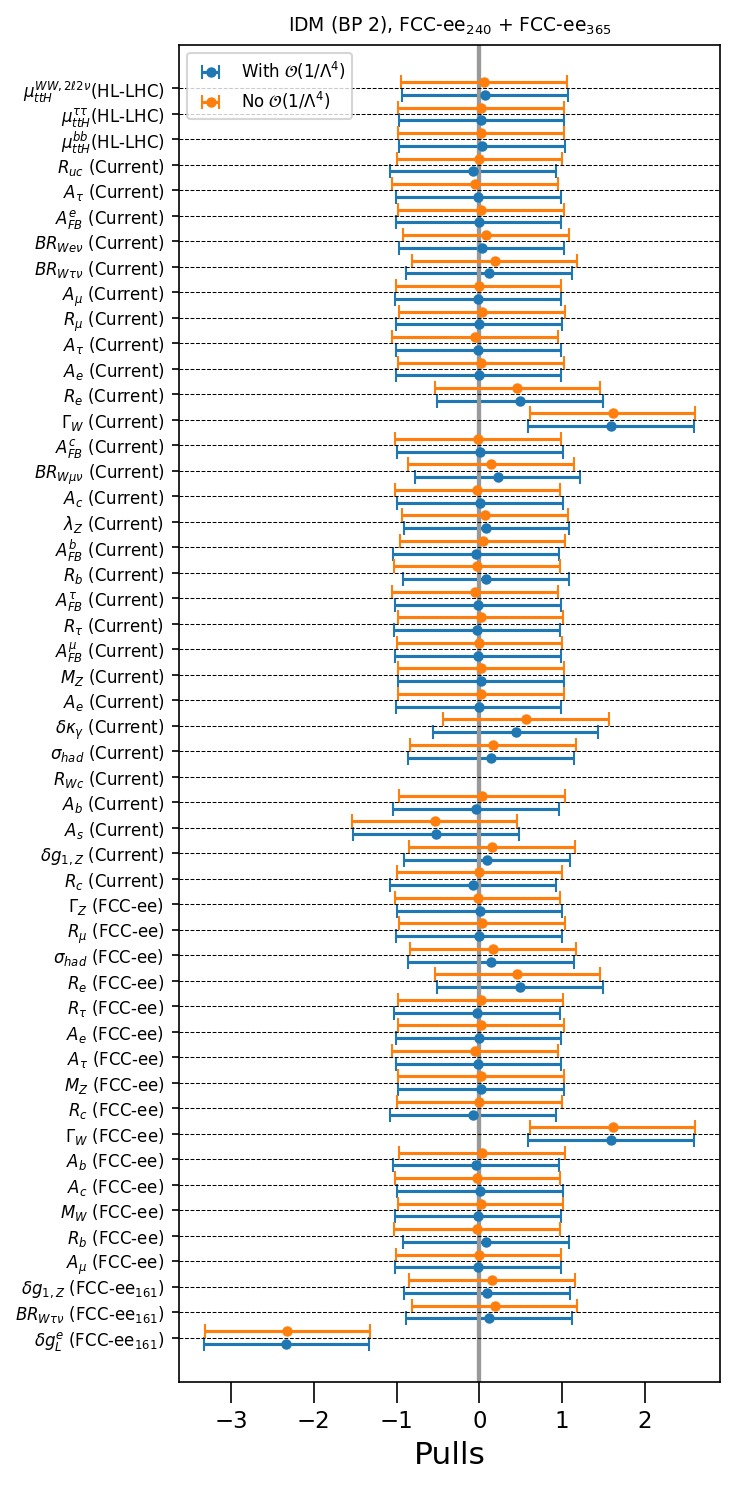

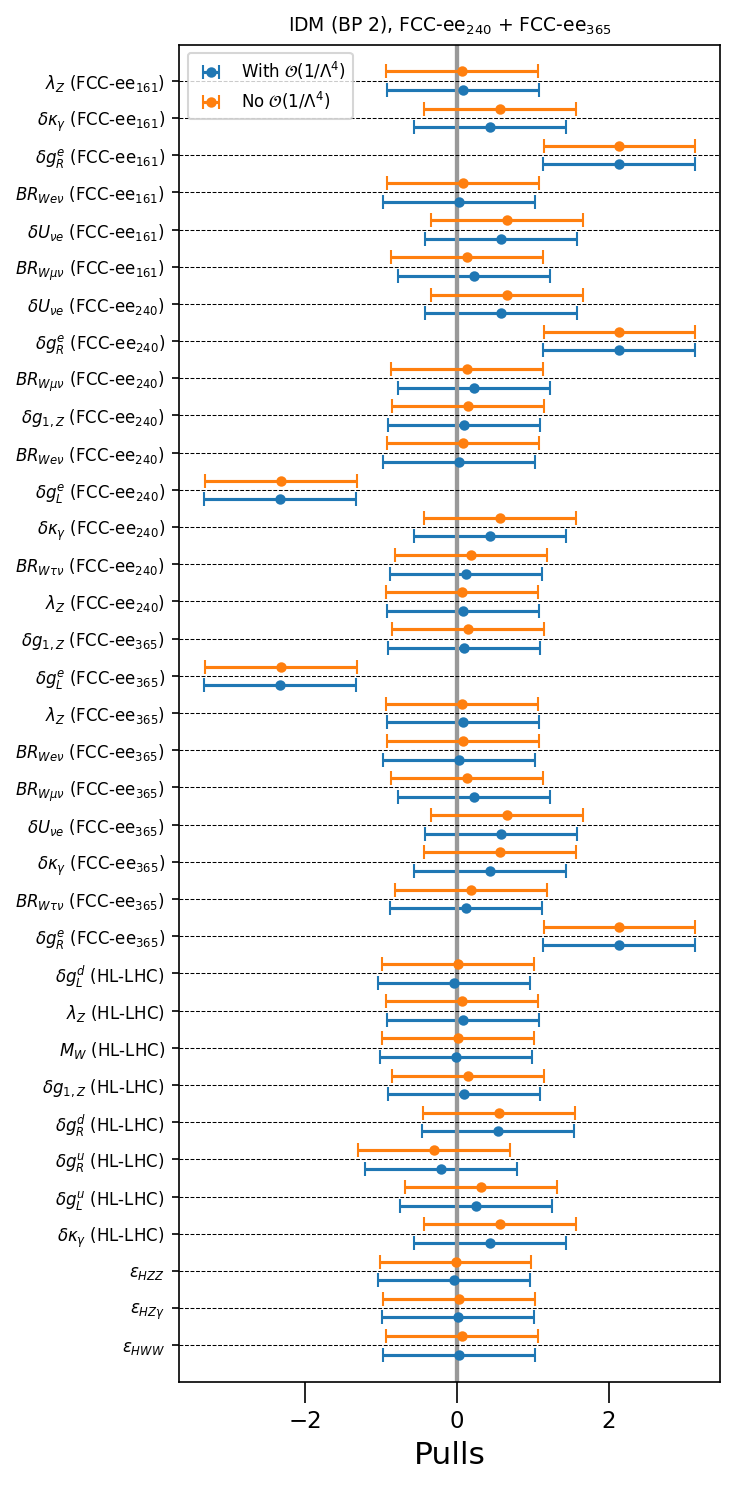

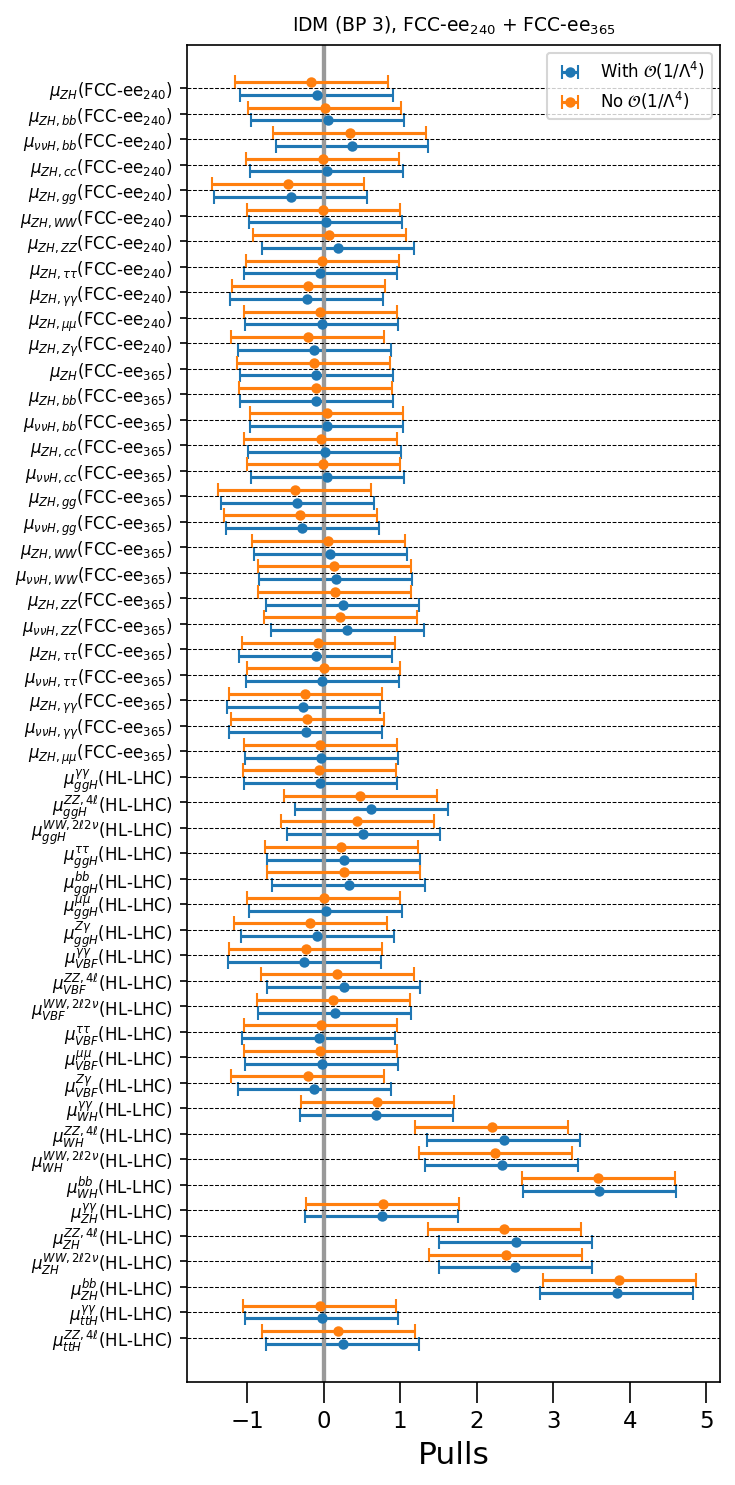

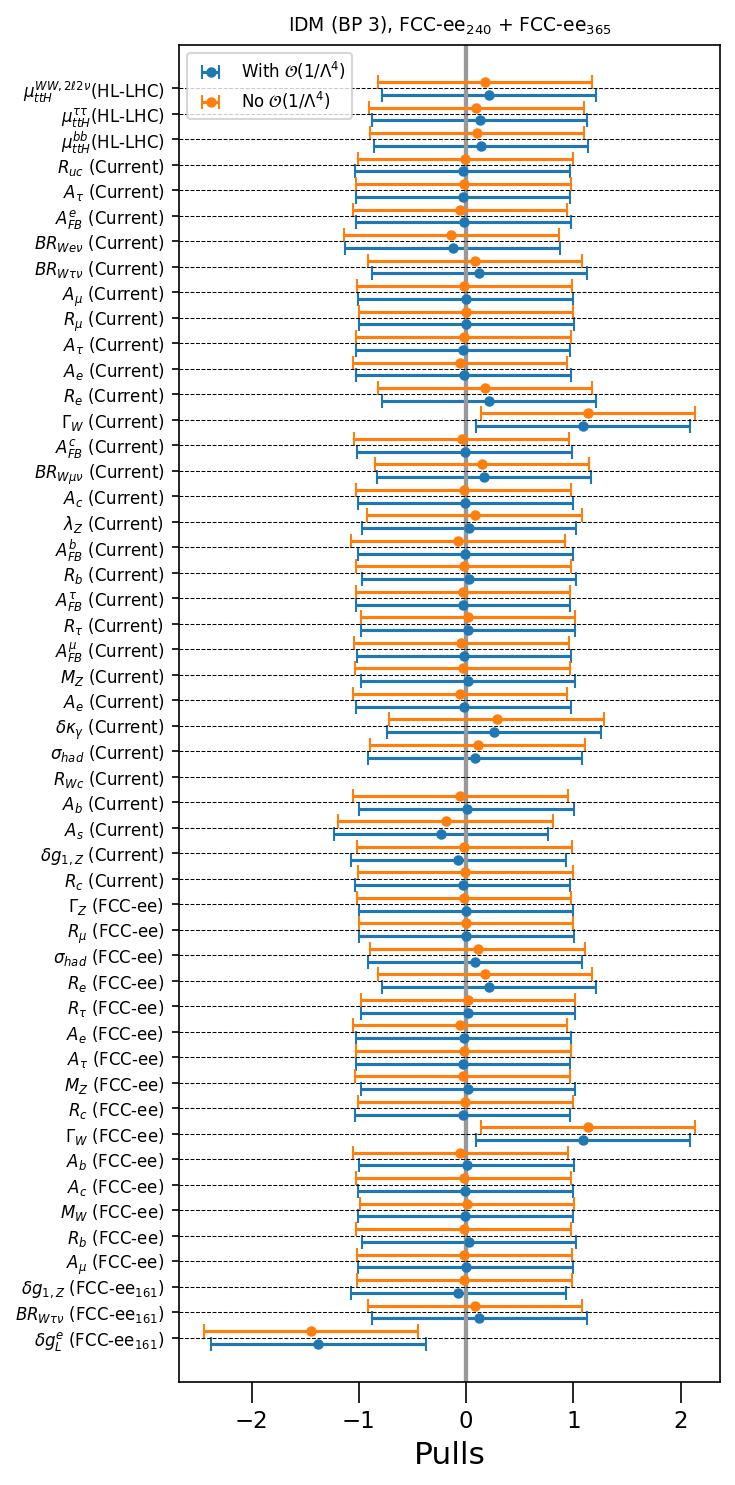

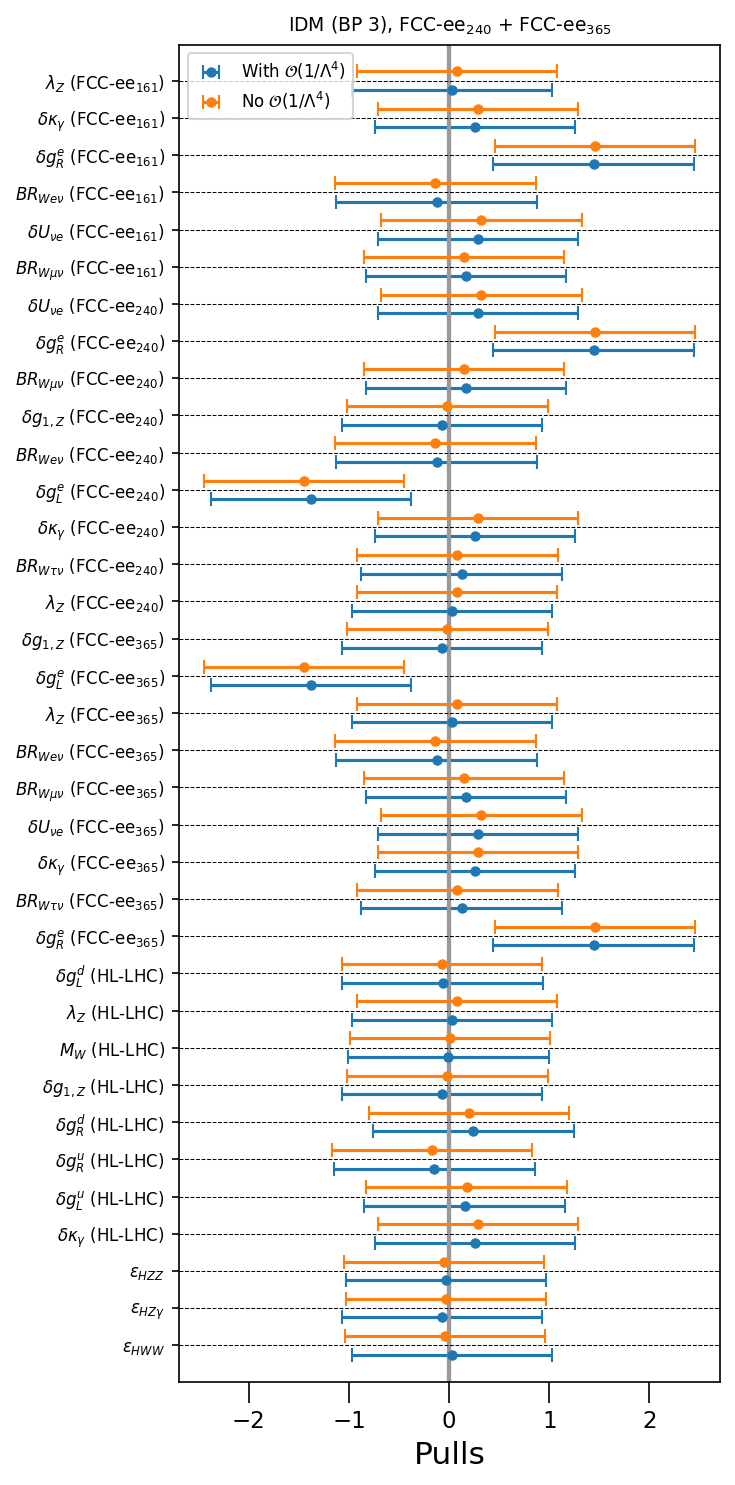

In [10]:
plot_titles = { 
    BP : {
        scenario : rf"{model} ({BP_name}), {scenario_title}"
        for scenario, scenario_title in zip(all_scenarios, scenario_titles)
    } 
    for BP, BP_name in zip(BPs, BP_names)
}

skip_obs = ["Mw_C", "GammaZ_C"]

pullplots.generate_pull_plots_obs(
    BPs=BPs,
    model_specs=model_specs,
    working_dir=working_dir,
    results_dir=results_dir_compare,
    model_specs_labels=model_specs_labels,
    plot_titles=plot_titles,
    model=model,
    colors=None,
    show_plots=True,
    nvar_per_plot=50,
    figsize=(5, 10),
    skip_obs=skip_obs
)

# One-loop IDM $\leftrightarrow$ SMEFT Matching

In [17]:
import pickle
vev = 246.
Mh = 125.

BP_input_dir = "/cephfs/user/mrebuzzi/phd/HiggsTools/future_projections/scan_output/IDM_scan_output"
BP_dicts_filename = f"{BP_input_dir}/Benchmark_Points_outliers_dicts.pkl"

with open(BP_dicts_filename, 'rb') as f:
    BPs = pickle.load(f)
    bp_kappas = BPs["kappas"][2::2]
    bp_EWPOs = BPs["EWPOs"][2::2]
    bp_model_pars = BPs["model_pars"][2::2]
    bp_indices = BPs["indices"][2::2]

print("BP kappas:", bp_kappas)
print("BP EWPOs:", bp_EWPOs)
print("BP model parameters:", bp_model_pars)
print("BP indices:", bp_indices)

mu2 = np.sqrt( np.array([bp["mu2sq"] for bp in bp_model_pars]) ); print("\nmu2:", mu2)
lam1 = np.array([bp["lam1"] for bp in bp_model_pars]); print("\nlam1:", lam1)
lam2 = np.array([bp["lam2"] for bp in bp_model_pars]); print("\nlam2:", lam2)
lam3 = np.array([bp["lam3"] for bp in bp_model_pars]); print("\nlam3:", lam3)
lam4 = np.array([bp["lam4"] for bp in bp_model_pars]); print("\nlam4:", lam4)
lam5 = np.array([bp["lam5"] for bp in bp_model_pars]); print("\nlam5:", lam5)
mH = np.array([bp["mH"] for bp in bp_model_pars]); print("\nmH:", mH)
mA = np.array([bp["mA"] for bp in bp_model_pars]); print("\nmA:", mA)
mHp = np.array([bp["mHp"] for bp in bp_model_pars]); print("\nmHp:", mHp)

bp_lambdas = np.array([bp["lam"] for bp in bp_kappas]); print("\nBP lambdas (1L):", bp_lambdas)
bp_lambdas_2L = np.array([bp["lam2L"] for bp in bp_kappas]); print("\nBP lambdas (2L):", bp_lambdas_2L)
bp_lambdas_2LDI = np.array([bp["lam2LDI"] for bp in bp_kappas]); print("\nBP lambdas (2LDI):", bp_lambdas_2LDI)

# IDM = EFT_matching.IDM(l1=lam1, l3=lam3, l4=lam4, l5=lam5, mu2=mu2)
IDM = EFT_matching.IDM.from_masses(mH=mH, mA=mA, mHp=mHp, mu2=mu2)
lamNP=1000 #GeV
# matched_WCs = IDM.get_coefficients(lamNP=lamNP, dimensionless=True)
matched_WCs = IDM.get_coefficients(lamNP=lamNP, dimensionless=False)
print("\nMatched Wilson coefficients at lamNP =", lamNP, "GeV:\n", matched_WCs)
matched_kappa_lambdas = IDM.get_kappa_lambda_SMEFT_match(lamNP=lamNP)
print("Matched SMEFT kappa_lambda at lamNP =", lamNP, "GeV:\n", matched_kappa_lambdas)
print("Model kappa_lambda predictions: ", bp_lambdas)

BP kappas: [{'uu': 0.997497286095468, 'dd': 0.997497286095468, 'ss': 0.997497286095468, 'cc': 0.997497286095468, 'bb': 0.997497286095468, 'tt': 0.997497286095468, 'ee': 0.997497286095468, 'mumu': 0.997497286095468, 'tautau': 0.997497286095468, 'ZZ_0': 0.99803003617002, 'ZZ_240': 0.9989225157021105, 'ZZ_365': 0.9985818760113092, 'ZZ_500': 0.9988812072771296, 'ZZ_550': 0.9990824850147142, 'ZZ': 0.9965497536506333, 'WW': 0.9965497536506333, 'lam': 1.1209067864736006, 'gamgam': 0.9821975068074829, 'Zgam': 0.9934043522024448, 'lam2L': 1.1445897207900972, 'lam2LDI': 1.1396677034680394, 'ZZ_0_with_WFR': 0.9978303652641312, 'ZZ_240_with_WFR': 0.9987243848566684, 'ZZ_365_with_WFR': 0.9983832518255341, 'ZZ_500_with_WFR': 0.9986830228142305, 'ZZ_550_with_WFR': 0.9988845456470622, 'ZZ_0_with_WFR_no_BSM': 1.000295978534025, 'ZZ_240_with_WFR_no_BSM': 1.000910770055903, 'ZZ_365_with_WFR_no_BSM': 1.0001978962466753, 'ZZ_500_with_WFR_no_BSM': 0.9999013780758704, 'ZZ_550_with_WFR_no_BSM': 0.999826024685

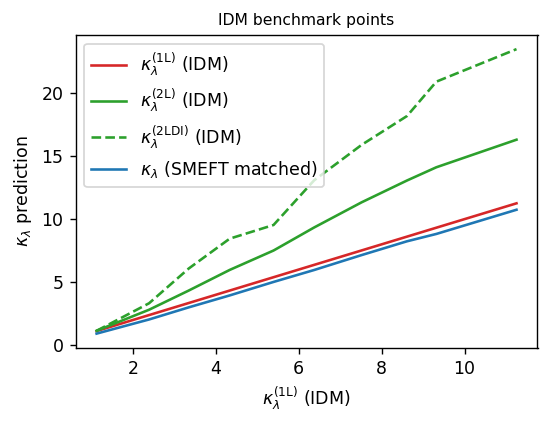

In [8]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

# Sort arrays
# sort_indices = np.argsort(bp_lambdas)
# print("Sort indices:", sort_indices)
# # mu2 = mu2[sort_indices]
# bp_lambdas = bp_lambdas[sort_indices]
# bp_lambdas_2L = bp_lambdas_2L[sort_indices]
# bp_lambdas_2LDI = bp_lambdas_2LDI[sort_indices]
# matched_kappa_lambdas = matched_kappa_lambdas[sort_indices]

ax.plot(bp_lambdas, bp_lambdas, color='tab:red', label=r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.plot(bp_lambdas, bp_lambdas_2L, color='tab:green', label=r'$\kappa_{\lambda}^{\mathrm{(2L)}}$ (IDM)')
ax.plot(bp_lambdas, bp_lambdas_2LDI, color='tab:green', ls="--", label=r'$\kappa_{\lambda}^{\mathrm{(2LDI)}}$ (IDM)')
ax.plot(bp_lambdas, matched_kappa_lambdas*(mu2/mA)**2, color='tab:blue', label=r'$\kappa_{\lambda}$ (SMEFT matched)')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_ylabel(r'$\kappa_{\lambda}$ prediction')
plt.title("IDM benchmark points",fontsize=9)
ax.legend()
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/kappa_lambda_matching_comparison.pdf")

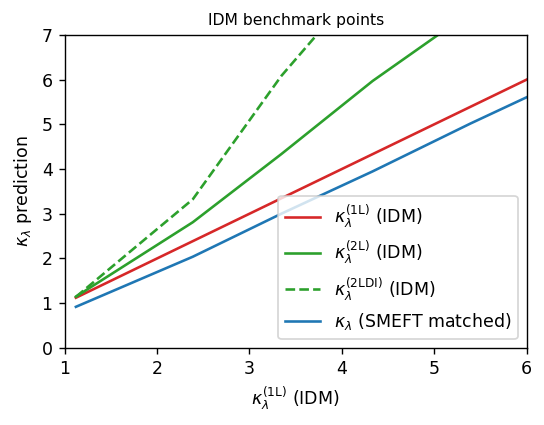

In [11]:
ax.set_xlim(1,6)
ax.set_ylim(0,7)
fig.savefig(f"{plot_dir}/kappa_lambda_matching_comparison_zoom.pdf")
fig

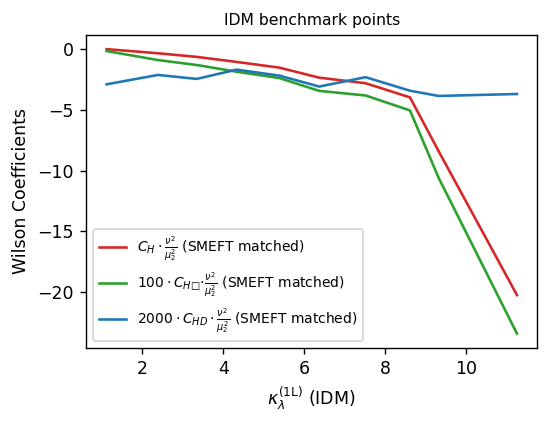

In [103]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

CH    = matched_WCs["CH"]    #[sort_indices]
CHbox = matched_WCs["CHbox"] #[sort_indices]
CHD   = matched_WCs["CHD"]   #[sort_indices]

ax.plot(bp_lambdas, CH*vev**2, color='tab:red', label=r'$C_{H}\cdot \frac{\nu^2}{\mu_{2}^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 100*CHbox*vev**2, color='tab:green', label='$100\cdot C_{H\u25A1}$'+r'$\cdot \frac{\nu^2}{\mu_{2}^{2}}$ (SMEFT matched)')
ax.plot(bp_lambdas, 2000*CHD*vev**2, color='tab:blue', label=r'$2000\cdot C_{HD}\cdot \frac{\nu^2}{\mu_{2}^{2}}$ (SMEFT matched)')
# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r'Wilson Coefficients')
ax.legend(fontsize=8)
plt.title("IDM benchmark points",fontsize=9)
plt.tight_layout()

plot_dir = "./comparison_plots/matching_comparison"
subprocess.run(["mkdir", "-p", plot_dir])
plt.savefig(f"{plot_dir}/WCs_matching_comparison.pdf")

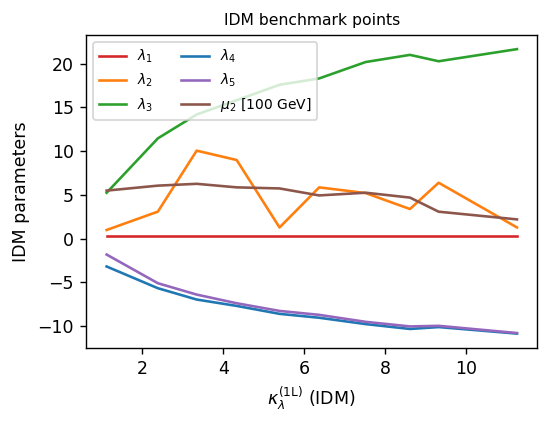

In [12]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

# lam1 = lam1[sort_indices]
# lam2 = lam2[sort_indices]
# lam3 = lam3[sort_indices]
# lam4 = lam4[sort_indices]
# lam5 = lam5[sort_indices]

ax.plot(bp_lambdas, lam1, color='tab:red', label=r'$\lambda_{1}$')
ax.plot(bp_lambdas, lam2, color='tab:orange', label=r'$\lambda_{2}$')
ax.plot(bp_lambdas, lam3, color='tab:green', label=r'$\lambda_{3}$')
ax.plot(bp_lambdas, lam4, color='tab:blue', label=r'$\lambda_{4}$')
ax.plot(bp_lambdas, lam5, color='tab:purple', label=r'$\lambda_{5}$')
ax.plot(bp_lambdas, mu2/100., color='tab:brown', label=r'$\mu_{2}$ [100 GeV]')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r'IDM parameters')
ax.legend(fontsize=8, ncol=2)
plt.title("IDM benchmark points",fontsize=9)
plt.tight_layout()

plt.savefig(f"{plot_dir}/IDM_parameters_matching_comparison.pdf")

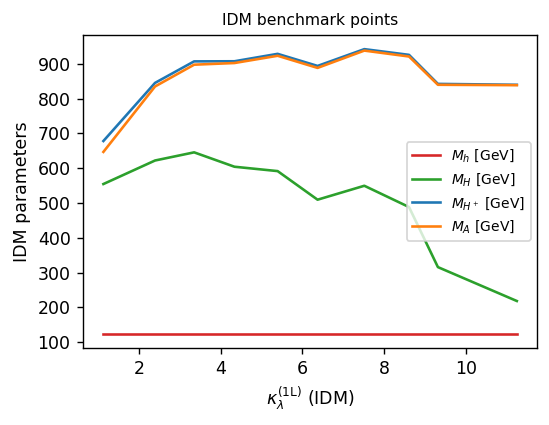

In [16]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, np.full_like(mH, Mh),  color='tab:red', label=r'$M_{h}$ [GeV]')
ax.plot(bp_lambdas, mH,  color='tab:green', label=r'$M_{H}$ [GeV]')
ax.plot(bp_lambdas, mHp, color='tab:blue', label=r'$M_{H^+}$ [GeV]')
ax.plot(bp_lambdas, mA,  color='tab:orange', label=r'$M_{A}$ [GeV]')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r'IDM parameters')
ax.legend(fontsize=8, ncol=1)
plt.title("IDM benchmark points",fontsize=9)
plt.tight_layout()

plt.savefig(f"{plot_dir}/IDM_parameters_masses_matching_comparison.pdf")

In [20]:
kappa_lambda_last_BP = 1 + (vev**2) * ( - 2 * vev**2 / Mh**2 * CH[-1] )
print("\nKappa_lambda of last BP from matched CH:", kappa_lambda_last_BP)
print("Matched CH for last BP:", CH[-1]*vev**2)


Kappa_lambda of last BP from matched CH: 157.66854541809843
Matched CH for last BP: -20.225609939171356


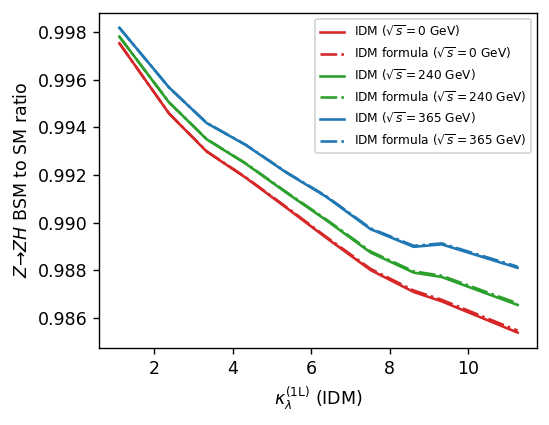

In [75]:
dZZh_SMEFT_sqrts0 = IDM.get_ZtoZH_SMEFT_match(sqrts=0.0)
dZZh_SMEFT_sqrts240 = IDM.get_ZtoZH_SMEFT_match(sqrts=240.0)
dZZh_SMEFT_sqrts365 = IDM.get_ZtoZH_SMEFT_match(sqrts=365.0)

dZZh_IDM_BPs_sqrt0   = np.array([bp["ZZ_0_pure_1L_BSM"]   for bp in bp_kappas])
dZZh_IDM_BPs_sqrt240 = np.array([bp["ZZ_240_pure_1L_BSM"] for bp in bp_kappas])
dZZh_IDM_BPs_sqrt365 = np.array([bp["ZZ_365_pure_1L_BSM"] for bp in bp_kappas])

dZZh_IDM_BPs_formula_sqrt0   = IDM.get_ZtoZH_IDM(sqrts=0.0)
dZZh_IDM_BPs_formula_sqrt240 = IDM.get_ZtoZH_IDM(sqrts=240.0)
dZZh_IDM_BPs_formula_sqrt365 = IDM.get_ZtoZH_IDM(sqrts=365.0)


fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

ax.plot(bp_lambdas, dZZh_IDM_BPs_sqrt0,  color='tab:red', linestyle='solid',  label=r'IDM ($\sqrt{s}=0$ GeV)')
# ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts0, color='tab:red', linestyle='dashed', label=r'SMEFT ($\sqrt{s}=0$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt0, color='tab:red', linestyle='-.', label=r'IDM formula ($\sqrt{s}=0$ GeV)')

ax.plot(bp_lambdas, dZZh_IDM_BPs_sqrt240,  color='tab:green', linestyle='solid',  label=r'IDM ($\sqrt{s}=240$ GeV)')
# ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts240, color='tab:green', linestyle='dashed', label=r'SMEFT ($\sqrt{s}=240$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt240, color='tab:green', linestyle='-.', label=r'IDM formula ($\sqrt{s}=240$ GeV)')

ax.plot(bp_lambdas, dZZh_IDM_BPs_sqrt365,  color='tab:blue',  linestyle='solid',  label=r'IDM ($\sqrt{s}=365$ GeV)')
# ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts365, color='tab:blue',  linestyle='dashed', label=r'SMEFT ($\sqrt{s}=365$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt365, color='tab:blue',  linestyle='-.', label=r'IDM formula ($\sqrt{s}=365$ GeV)')

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r"$Z\to ZH$ BSM to SM ratio")
ax.legend(fontsize=7, ncol=1)
# ax.set_ylim(0.95, 1.0)
plt.tight_layout()

plt.savefig(f"{plot_dir}/ZZh_couplings_matching_comparison.pdf")

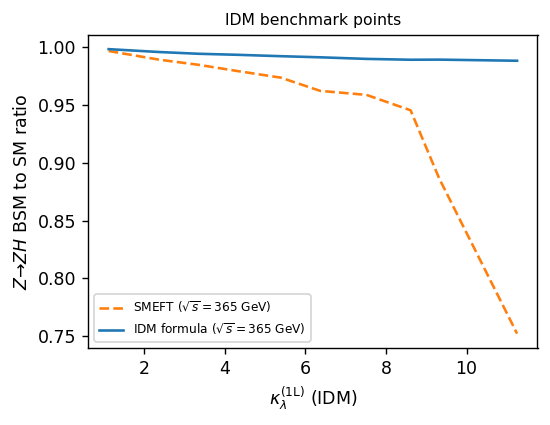

In [105]:
fig = plt.figure(figsize=(4.5,3.5))
ax = plt.gca()

# ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts0, color='tab:red', linestyle='dashed', label=r'SMEFT ($\sqrt{s}=0$ GeV)')
# ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt0, color='tab:red', linestyle='-', label=r'IDM formula ($\sqrt{s}=0$ GeV)')

# ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts240, color='tab:green', linestyle='dashed', label=r'SMEFT ($\sqrt{s}=240$ GeV)')
# ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt240, color='tab:green', linestyle='-', label=r'IDM formula ($\sqrt{s}=240$ GeV)')

ax.plot(bp_lambdas, 1+dZZh_SMEFT_sqrts365, color='tab:orange',  linestyle='dashed', label=r'SMEFT ($\sqrt{s}=365$ GeV)')
ax.plot(bp_lambdas, 1+dZZh_IDM_BPs_formula_sqrt365, color='tab:blue',  linestyle='-', label=r'IDM formula ($\sqrt{s}=365$ GeV)')
plt.title("IDM benchmark points",fontsize=9)

# ax.set_xlabel(r'$\mu_{2}$ [GeV]')
ax.set_xlabel(r'$\kappa_{\lambda}^{\mathrm{(1L)}}$ (IDM)')
ax.set_ylabel(r"$Z\to ZH$ BSM to SM ratio")
ax.legend(fontsize=7, ncol=1)
# ax.set_ylim(0.95, 1.0)
plt.tight_layout()

plt.savefig(f"{plot_dir}/ZZh_couplings_matching_comparison.pdf")

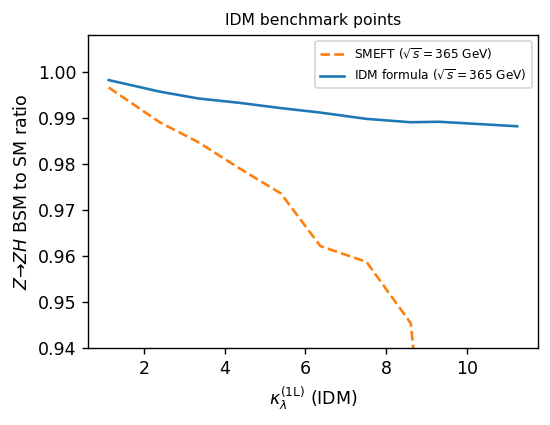

In [106]:
ax.set_ylim(0.94, 1.008)
fig.savefig(f"{plot_dir}/ZZh_couplings_matching_comparison_zoom.pdf")
fig

In [38]:
print("Testing get_BSM_masses() function:")
mH_formula, mA_formula, mHp_formula = IDM.get_BSM_masses()
print(f"mH = {mH}")
print(f"mH (formula) = {mH_formula}")
print(f"mH difference = {mH - mH_formula}")

print(f"mA = {mA}")
print(f"mA (formula) = {mA_formula}")
print(f"mA difference = {mA - mA_formula}")

print(f"mHp = {mHp}")
print(f"mHp (formula) = {mHp_formula}")
print(f"mHp difference = {mHp - mHp_formula}")

Testing get_BSM_masses() function:
mH = [554.56742675 622.15467211 645.56111752 604.27081307 591.71024225
 509.59825321 549.61779022 488.45548743 315.98326629 218.62433154]
mH (formula) = [554.56742675 622.15467211 645.56111752 604.27081307 591.71024225
 509.59825321 549.61779022 488.45548743 315.98326629 218.62433154]
mH difference = [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  1.13686838e-13 -5.68434189e-14  0.00000000e+00 -5.68434189e-14
 -5.68434189e-14  8.52651283e-14]
mA = [646.82577261 834.75825277 897.32117184 902.07603173 922.95603984
 888.09829276 937.79238476 920.81044239 839.62823708 838.45373946]
mA (formula) = [646.82577261 834.75825277 897.32117184 902.07603173 922.95603984
 888.09829276 937.79238476 920.81044239 839.62823708 838.45373946]
mA difference = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
mHp = [678.09236912 845.05538978 906.84467762 907.17900217 928.45793132
 893.74355164 941.9849384  925.57135169 842.18963192 839.61666905]
mHp (formula) = [678.09236

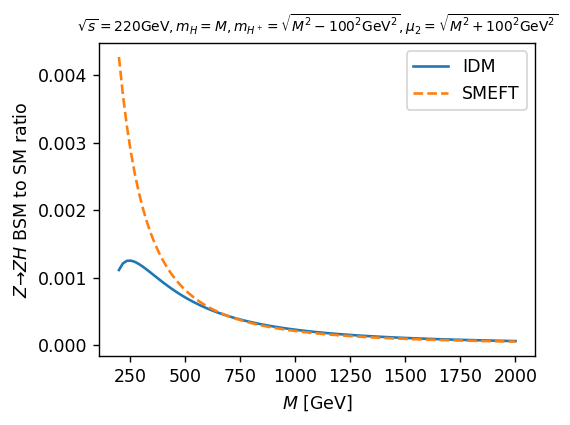

In [110]:
M_range = np.linspace(200, 2000, 100)
sqrts_val = 220

mH = M_range; mA = np.sqrt(M_range**2 + 400**2); mHp = np.sqrt(M_range**2 - 100**2); mu2 = np.sqrt(M_range**2 + 100**2)
IDM_scenario = EFT_matching.IDM.from_masses(mH=mH, mA=mA, mHp=mHp, mu2=mu2)
IDM_vals = IDM_scenario.get_ZtoZH_IDM(sqrts=sqrts_val)
SMEFT_vals = IDM_scenario.get_ZtoZH_SMEFT_match(sqrts=sqrts_val)

fig = plt.figure(figsize=(4.5,3.5))
plt.plot(M_range, IDM_vals, label="IDM")
plt.plot(M_range, SMEFT_vals, label="SMEFT", linestyle="dashed")
plt.title(
    r"$\sqrt{s} = 220\mathrm{GeV},m_H = M, m_{H^+} = \sqrt{M^2 - 100^2\mathrm{GeV}^2}, \mu_2 = \sqrt{M^2 + 100^2\mathrm{GeV}^2}$",
    fontsize=8
)
plt.xlabel(r"$M$ [GeV]")
plt.ylabel(r"$Z\to ZH$ BSM to SM ratio")
# plt.ylim(0.0, 0.005)
plt.legend()
plt.tight_layout()
# plt.show()
plt.savefig(f"{plot_dir}/ZZh_couplings_matching_comparison_Henning.pdf")

In [ ]:
from pyCollier import db0 as dB0
a = np.array([100**2, 100**2])
b = np.array([200**2, 300**2])
c = np.array([200**2, 200**2])
dB0(a,b,c)
# Not vectorized!!

(4.386818141942566e-06+0j)